In [670]:
#import libraries 
import pandas as pd
import sqlite3
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns

In [671]:
#read data
conn = sqlite3.connect('/Users/rango/documents/projects/SoccerForecast/database.sqlite')
match_df = pd.read_sql_query("SELECT * FROM Match", conn)
team_attrb_df = pd.read_sql_query("SELECT * FROM Team_attributes", conn)

In [672]:
display(match_df.head())

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


we decided to drop all post-match related columns.

In [673]:
print(match_df.columns.to_list())

['id', 'country_id', 'league_id', 'season', 'stage', 'date', 'match_api_id', 'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'home_player_X1', 'home_player_X2', 'home_player_X3', 'home_player_X4', 'home_player_X5', 'home_player_X6', 'home_player_X7', 'home_player_X8', 'home_player_X9', 'home_player_X10', 'home_player_X11', 'away_player_X1', 'away_player_X2', 'away_player_X3', 'away_player_X4', 'away_player_X5', 'away_player_X6', 'away_player_X7', 'away_player_X8', 'away_player_X9', 'away_player_X10', 'away_player_X11', 'home_player_Y1', 'home_player_Y2', 'home_player_Y3', 'home_player_Y4', 'home_player_Y5', 'home_player_Y6', 'home_player_Y7', 'home_player_Y8', 'home_player_Y9', 'home_player_Y10', 'home_player_Y11', 'away_player_Y1', 'away_player_Y2', 'away_player_Y3', 'away_player_Y4', 'away_player_Y5', 'away_player_Y6', 'away_player_Y7', 'away_player_Y8', 'away_player_Y9', 'away_player_Y10', 'away_player_Y11', 'home_player_1', 'home_player_2', 'home_player_

In [674]:
# Drop unnecessary columns
cols_to_drop = ['season', 'date', 'shoton', 'shotoff', 'foulcommit', 'card', 'cross', 'corner', 'possession', 'goal','SJA','SJD','SJH']
match_df.drop(columns=cols_to_drop, axis=1, inplace=True)
match_df.drop(list(match_df.filter(regex='player')), axis=1, inplace=True)
match_df.drop(list(match_df.filter(regex='id')), axis=1, inplace=True)
# All these rows are nulls except for fields in stage column
match_df.dropna(subset=['B365H'], inplace=True)



In [675]:
y = pd.DataFrame()
y['home_outcome'] = match_df.apply(lambda x: 0 if x['away_team_goal'] > x['home_team_goal'] else (
            1 if x['home_team_goal'] > x['away_team_goal'] else 2), axis=1)
display(y.head())

,home_outcome
0,2
1,2
2,0
3,1
4,0


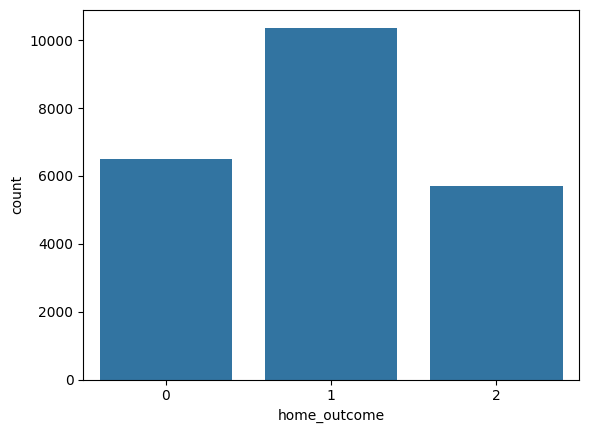

In [676]:
# Assuming df is your DataFrame
sns.countplot(x='home_outcome', data=y)
plt.show()

In [677]:
match_df.drop(list(match_df.filter(regex='goal')), axis=1, inplace=True)
display(match_df.head())

,stage,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,...,WHA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1.73,3.40,5.00,1.75,3.35,4.20,1.85,3.2,3.5,...,4.33,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,1,1.95,3.20,3.60,1.80,3.30,3.95,1.90,3.2,3.5,...,3.60,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,1,2.38,3.30,2.75,2.40,3.30,2.55,2.60,3.1,2.3,...,2.40,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,1,1.44,3.75,7.50,1.40,4.00,6.80,1.40,3.9,6.0,...,6.00,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,1,5.00,3.50,1.65,5.00,3.50,1.60,4.00,3.3,1.7,...,1.70,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [678]:
match_df.describe()

,stage,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,...,WHA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
count,22592.000000,22592.000000,22592.000000,22592.000000,22572.000000,22572.000000,22572.000000,22516.000000,22516.000000,22516.000000,...,22568.000000,22566.000000,22566.000000,22566.000000,14160.000000,14160.000000,14160.000000,14160.000000,14160.000000,14160.000000
mean,18.472867,2.628818,3.839684,4.662222,2.559328,3.747723,4.396720,2.467748,3.608752,4.149605,...,4.482306,2.668161,3.899139,4.840256,2.498834,3.648355,4.352758,2.497823,3.660907,4.405056
std,10.507703,1.794463,1.118269,3.730104,1.638071,1.033463,3.292378,1.445715,0.802450,2.856569,...,3.585131,1.928828,1.248225,4.318527,1.489385,0.867383,3.010148,1.507822,0.868082,3.189109
min,1.000000,1.040000,1.400000,1.080000,1.030000,1.650000,1.100000,1.050000,1.500000,1.100000,...,1.080000,1.030000,1.620000,1.080000,1.050000,1.450000,1.120000,1.040000,1.400000,1.120000
25%,9.000000,1.670000,3.300000,2.500000,1.650000,3.200000,2.500000,1.650000,3.200000,2.500000,...,2.500000,1.700000,3.300000,2.550000,1.670000,3.200000,2.500000,1.670000,3.250000,2.500000
50%,18.000000,2.100000,3.500000,3.500000,2.100000,3.400000,3.400000,2.100000,3.300000,3.300000,...,3.400000,2.150000,3.500000,3.500000,2.100000,3.300000,3.400000,2.100000,3.400000,3.400000
75%,27.000000,2.800000,4.000000,5.250000,2.750000,3.800000,5.000000,2.600000,3.700000,4.600000,...,5.000000,2.800000,4.000000,5.400000,2.650000,3.750000,5.000000,2.620000,3.750000,5.000000
max,38.000000,26.000000,17.000000,51.000000,34.000000,19.500000,51.000000,20.000000,11.000000,25.000000,...,51.000000,36.000000,26.000000,67.000000,21.000000,11.000000,34.000000,17.000000,13.000000,34.000000


In [679]:
percent_missing = match_df.isnull().sum() * 100 / len(match_df)
missing_value_df = pd.DataFrame({'column_name': match_df.columns,
                                 'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
print(missing_value_df)

      column_name  percent_missing
stage       stage         0.000000
B365H       B365H         0.000000
B365D       B365D         0.000000
B365A       B365A         0.000000
BWH           BWH         0.088527
BWD           BWD         0.088527
BWA           BWA         0.088527
WHA           WHA         0.106232
WHD           WHD         0.106232
WHH           WHH         0.106232
VCH           VCH         0.115085
VCA           VCA         0.115085
VCD           VCD         0.115085
LBA           LBA         0.172627
LBD           LBD         0.172627
LBH           LBH         0.172627
IWA           IWA         0.336402
IWD           IWD         0.336402
IWH           IWH         0.336402
BSH           BSH        37.322946
GBA           GBA        37.322946
GBD           GBD        37.322946
BSA           BSA        37.322946
BSD           BSD        37.322946
GBH           GBH        37.322946
PSA           PSA        50.570999
PSD           PSD        50.570999
PSH           PSH   

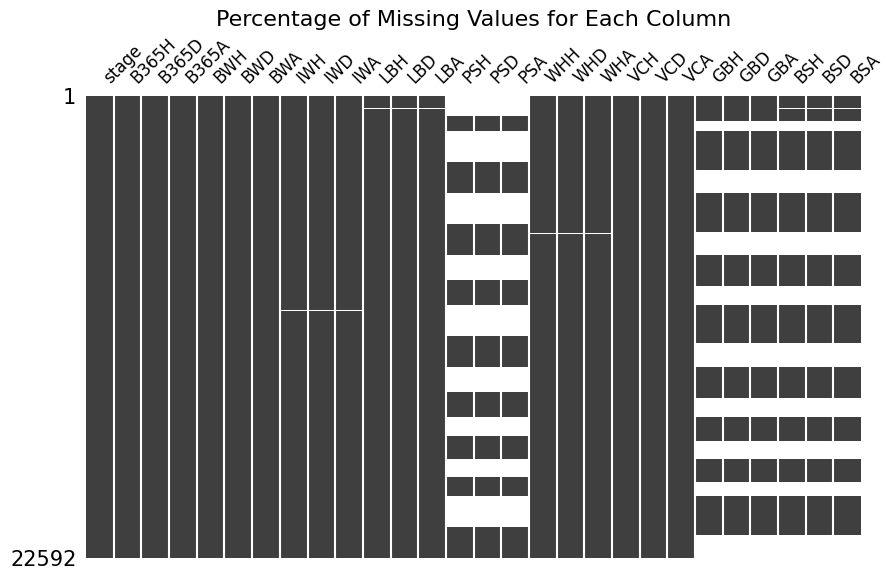

In [680]:
msno.matrix(match_df, figsize=(10, 6), sparkline=False, fontsize=12)
plt.title('Percentage of Missing Values for Each Column', fontsize=16)
plt.show()

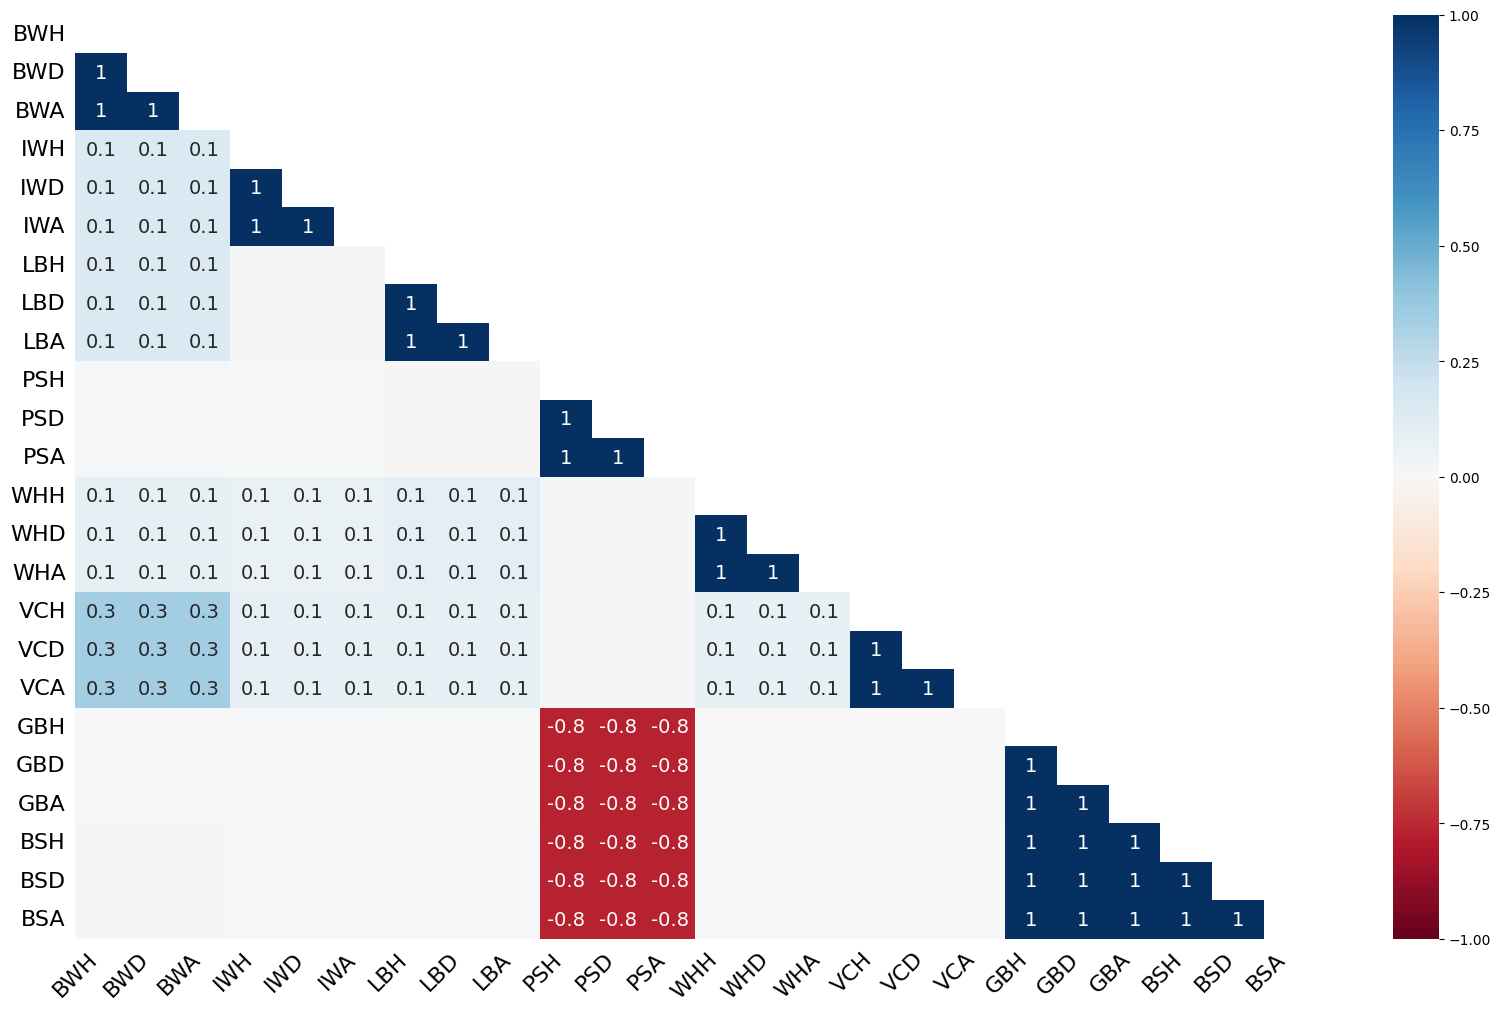

In [681]:
msno.heatmap(match_df)
plt.show()

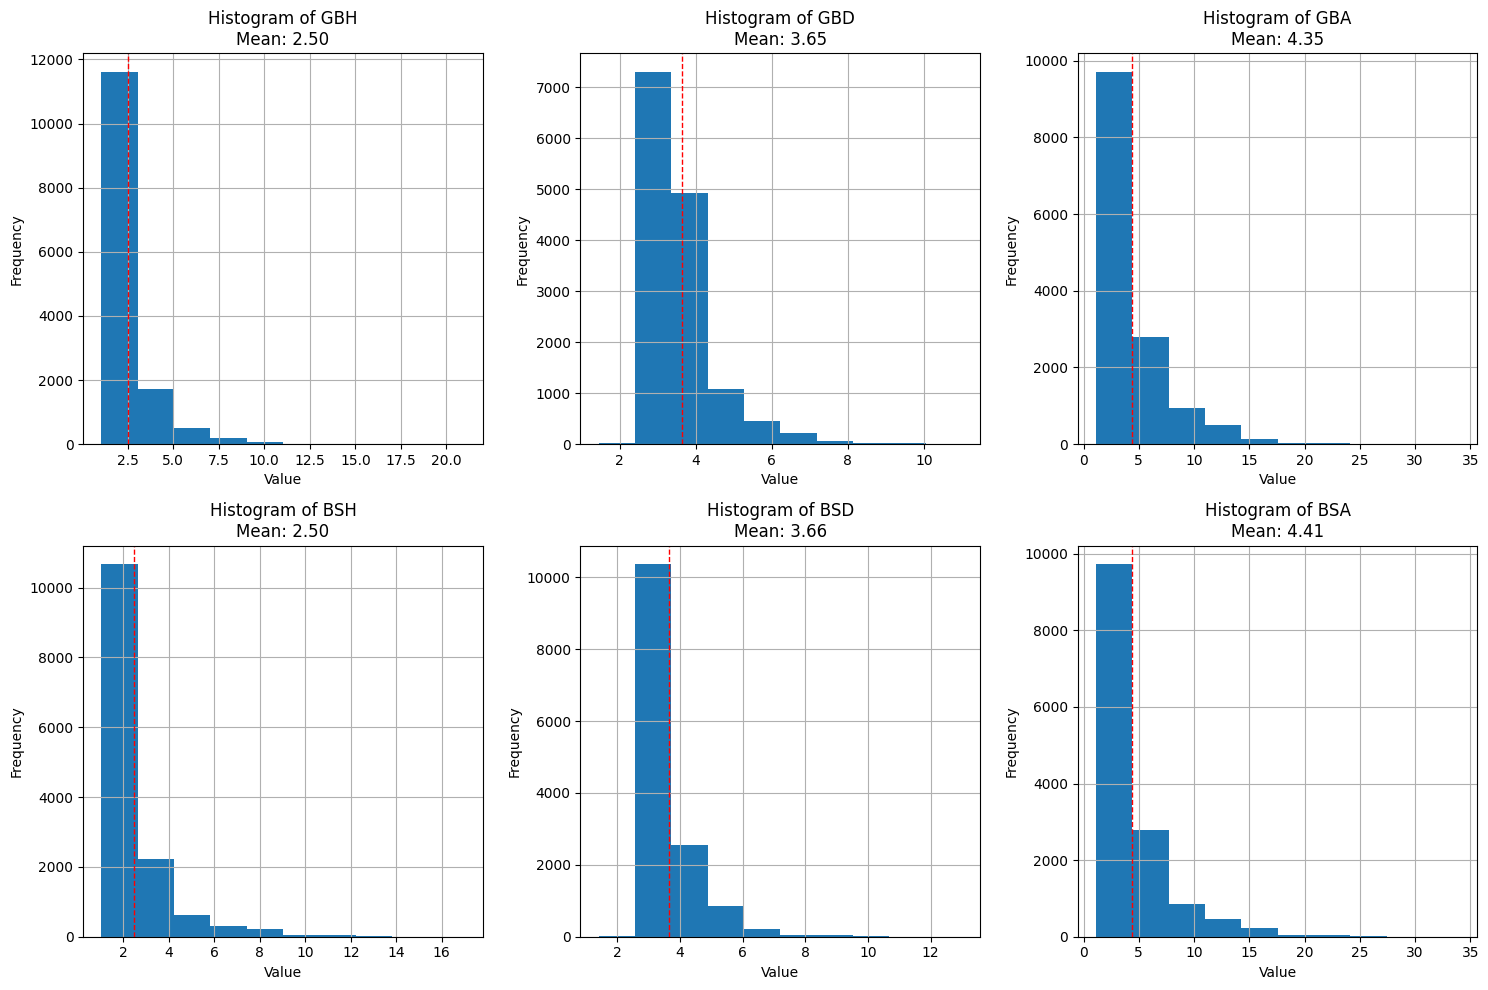

In [682]:
columns = ['GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, column in enumerate(columns):
    row = i // 3
    col = i % 3
    mean_value = match_df[column].mean()  # Calculate the mean of the column
    match_df[column].hist(ax=axes[row, col])
    axes[row, col].axvline(mean_value, color='r', linestyle='dashed', linewidth=1)  # Plot mean as a red dashed line
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Histogram of {column}\nMean: {mean_value:.2f}')

plt.tight_layout()
plt.show()
